# Part 1: McCulloch-Pitts Neuron (1943)

## Implementation of the Basic Neuron Model
This section implements the McCulloch-Pitts neuron, a simplified model of a biological neuron. It takes binary inputs, multiplies them by weights, sums them up, and applies a threshold to produce a binary output.

In [1]:
import numpy as np

def mp_neuron(inputs, weights, threshold):
    """McCulloch-Pitts neuron model."""
    weighted_sum = np.dot(inputs, weights)
    return 1 if weighted_sum >= threshold else 0

## Construction of Logic Gates
Here, we demonstrate how to construct basic logic gates (AND, OR, NOT, NAND, NOR) using the McCulloch-Pitts neuron by setting appropriate weights and thresholds.

In [2]:
# Inputs for 2-input logic gates
inputs = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])

# AND Gate
weights_and = np.array([1, 1])
threshold_and = 2
print("AND Gate:")
for i in inputs:
    print(f"{i} -> {mp_neuron(i, weights_and, threshold_and)}")

# OR Gate
weights_or = np.array([1, 1])
threshold_or = 1
print("\nOR Gate:")
for i in inputs:
    print(f"{i} -> {mp_neuron(i, weights_or, threshold_or)}")

# NOT Gate (single input)
weights_not = np.array([-1])
threshold_not = 0
print("\nNOT Gate:")
for i in [0, 1]:
    print(f"{i} -> {mp_neuron(np.array([i]), weights_not, threshold_not)}")

# NAND Gate
weights_nand = np.array([-1, -1])
threshold_nand = -1
print("\nNAND Gate:")
for i in inputs:
    print(f"{i} -> {mp_neuron(i, weights_nand, threshold_nand)}")

# NOR Gate
weights_nor = np.array([-1, -1])
threshold_nor = 0
print("\nNOR Gate:")
for i in inputs:
    print(f"{i} -> {mp_neuron(i, weights_nor, threshold_nor)}")

AND Gate:
[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1

OR Gate:
[0 0] -> 0
[0 1] -> 1
[1 0] -> 1
[1 1] -> 1

NOT Gate:
0 -> 1
1 -> 0

NAND Gate:
[0 0] -> 1
[0 1] -> 1
[1 0] -> 1
[1 1] -> 0

NOR Gate:
[0 0] -> 1
[0 1] -> 0
[1 0] -> 0
[1 1] -> 0


## Demonstration of XOR Impossibility
A single McCulloch-Pitts neuron cannot implement the XOR gate because XOR is not a linearly separable function. This section explains why.

A single MP neuron can only create a linear decision boundary. For a 2-input gate, this is a line. The XOR function requires a non-linear boundary to separate the `(0,1)` and `(1,0)` inputs (which should output 1) from the `(0,0)` and `(1,1)` inputs (which should output 0). You cannot draw a single straight line to do this.

## Implementation of a 3-Neuron Network for XOR
To solve the XOR problem, we can use a network of neurons. A common solution is a 3-neuron network: two neurons in the first layer (one for NAND, one for OR) and one neuron in the second layer (for AND). The expression is `(A OR B) AND (A NAND B)`.

In [3]:
def xor_network(inputs):
    # Neuron 1: NAND
    nand_out = mp_neuron(inputs, weights_nand, threshold_nand)
    # Neuron 2: OR
    or_out = mp_neuron(inputs, weights_or, threshold_or)
    # Neuron 3: AND (takes outputs of NAND and OR as inputs)
    final_inputs = np.array([nand_out, or_out])
    return mp_neuron(final_inputs, weights_and, threshold_and)

print("\nXOR Network:")
for i in inputs:
    print(f"{i} -> {xor_network(i)}")


XOR Network:
[0 0] -> 0
[0 1] -> 1
[1 0] -> 1
[1 1] -> 0


## Visualization of Decision Boundaries
This section provides visualizations of the decision boundaries for the 2-input logic gates. This helps to understand how the neuron separates the input space.

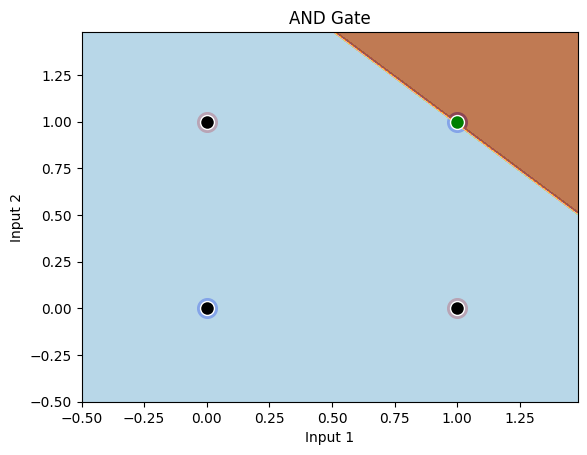

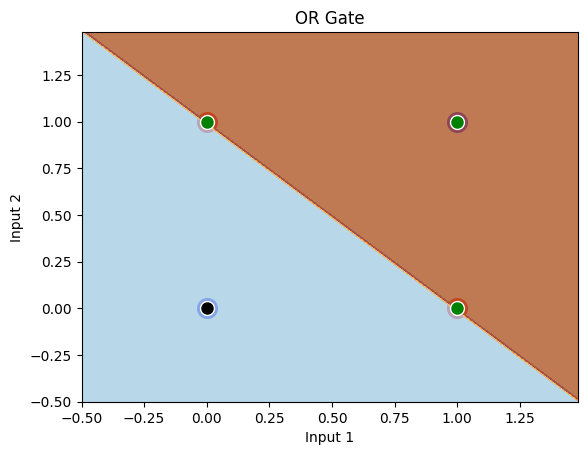

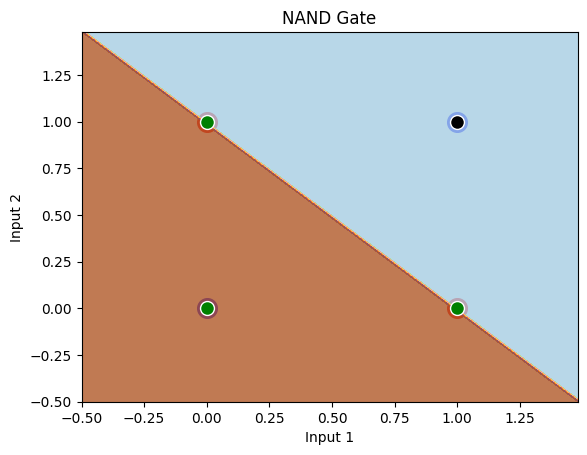

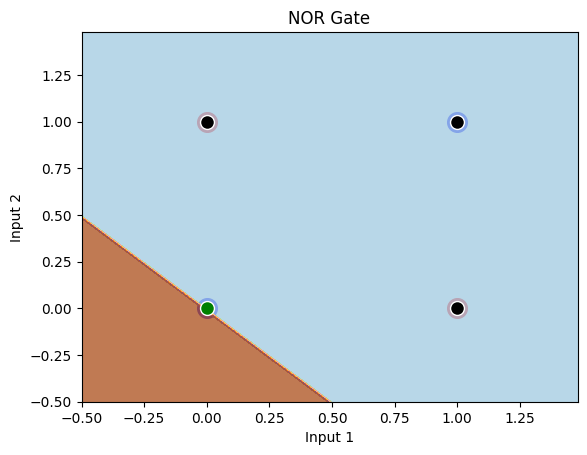

In [4]:
import matplotlib.pyplot as plt

def plot_decision_boundary(weights, threshold, title):
    fig, ax = plt.subplots()
    ax.set_title(title)
    ax.set_xlabel("Input 1")
    ax.set_ylabel("Input 2")
    
    # Plot points
    ax.scatter([0, 1], [0, 1], c='blue', s=200)
    ax.scatter([0, 1], [1, 0], c='red', s=200)

    # Create a mesh to plot in
    h = .02  # step size in the mesh
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Plot the decision boundary
    Z = np.array([mp_neuron(np.array([x,y]), weights, threshold) for x, y in np.c_[xx.ravel(), yy.ravel()]])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.8)

    # Plot the four input points
    for i in inputs:
        output = mp_neuron(i, weights, threshold)
        color = 'g' if output == 1 else 'k'
        ax.scatter(i[0], i[1], color=color, s=100, edgecolor='w')

    plt.show()

plot_decision_boundary(weights_and, threshold_and, "AND Gate")
plot_decision_boundary(weights_or, threshold_or, "OR Gate")
plot_decision_boundary(weights_nand, threshold_nand, "NAND Gate")
plot_decision_boundary(weights_nor, threshold_nor, "NOR Gate")